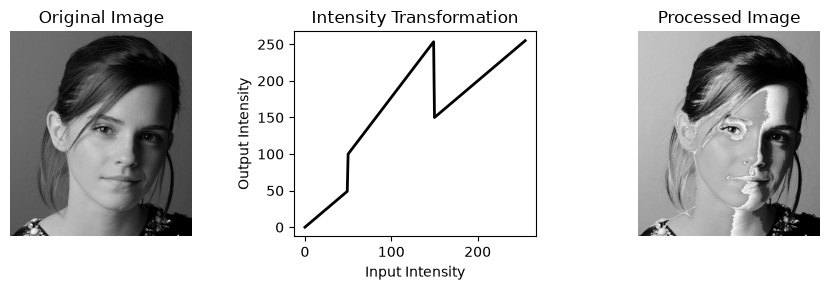

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

def intensity_transformation(im, breakpoints):
    input_values = breakpoints[:, 0]
    output_values = breakpoints[:, 1]
    transformed_im = np.interp(im.flatten(), input_values, output_values)
    return transformed_im.reshape(im.shape)

breakpoints = np.array([
    [0, 0],
    [50, 50],
    [50, 100],   
    [150, 255],
    [150, 150],
    [255, 255]
], dtype=np.uint8)

x = np.arange(256, dtype=np.uint8)
y = intensity_transformation(x, breakpoints)
im = cv.imread('images/emma.jpg', cv.IMREAD_GRAYSCALE)
assert im is not None, "Image not found. Please check the path."
processed_im = intensity_transformation(im, breakpoints)

fig, ax = plt.subplots(1, 3, figsize=(9, 3))

ax[0].imshow(im, cmap='gray')
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].plot(x, y, 'black', linewidth=2)
ax[1].set_xlabel('Input Intensity')
ax[1].set_ylabel('Output Intensity')
ax[1].set_title('Intensity Transformation')

ax[2].imshow(processed_im, cmap='gray')
ax[2].set_title('Processed Image')
ax[2].axis('off')

plt.tight_layout()
plt.show()


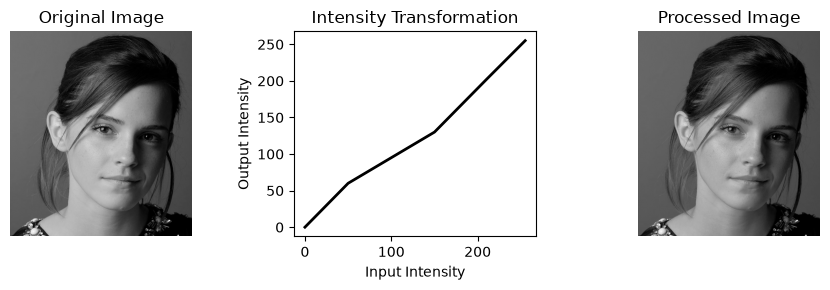

In [3]:
breakpoints = np.array([
    [0, 0], 
    [50, 60], 
    [150, 130], 
    [200, 190], 
    [255, 255]
], dtype=np.uint8)

x = np.arange(256, dtype=np.uint8)
y = intensity_transformation(x, breakpoints)
im = cv.imread('images/emma.jpg', cv.IMREAD_GRAYSCALE)
processed_im = intensity_transformation(im, breakpoints)

fig, ax = plt.subplots(1, 3, figsize=(9, 3))

ax[0].imshow(im, cmap='gray')
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].plot(x, y, 'black', linewidth=2)
ax[1].set_xlabel('Input Intensity')
ax[1].set_ylabel('Output Intensity')
ax[1].set_title('Intensity Transformation')

ax[2].imshow(processed_im, cmap='gray')
ax[2].set_title('Processed Image')
ax[2].axis('off')

plt.tight_layout()
plt.show()

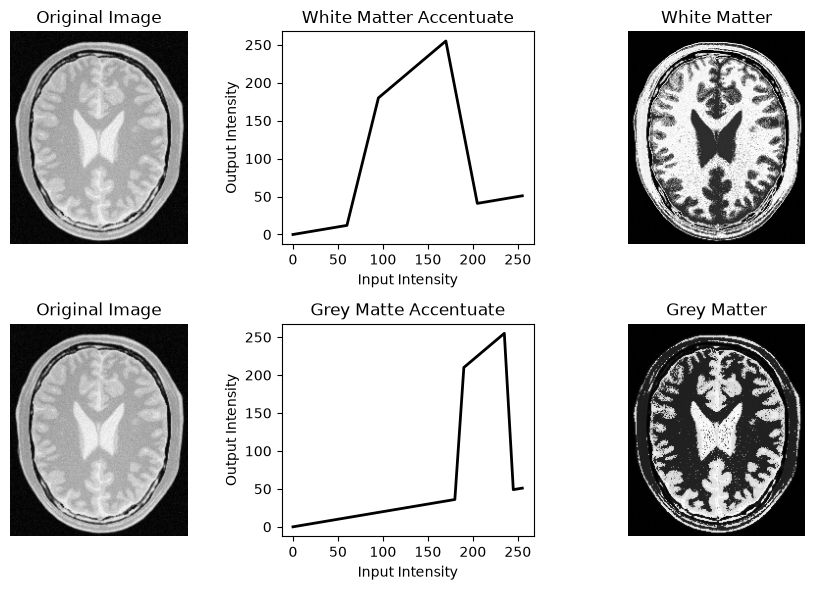

In [55]:
im = cv.imread('images/brain_proton_density_slice.png', cv.IMREAD_GRAYSCALE)
assert im is not None, "Image not found. Please check the path."

# White Accentuate
breakpoints_1 = np.array([
    [0, 0], 
    [60, 12], 
    [95, 180], 
    [170, 255],
    [205, 41],
    [255, 51]
], dtype=np.uint8)

y_1 = intensity_transformation(x, breakpoints_1)
processed_im = intensity_transformation(im, breakpoints_1)

# Grey Accentuate
breakpoints_2 = np.array([
    [0, 0], 
    [180, 36],
    [190, 210],
    [235, 255],
    [245, 49],
    [255, 51]
], dtype=np.uint8)

y_2 = intensity_transformation(x, breakpoints_2)
processed_im_2 = intensity_transformation(im, breakpoints_2)

fig, ax = plt.subplots(2, 3, figsize=(9, 6))

ax[0, 0].imshow(im, cmap='gray')
ax[0, 0].set_title('Original Image')
ax[0, 0].axis('off')
ax[0, 1].plot(x, y_1, 'black', linewidth=2)
ax[0, 1].set_xlabel('Input Intensity')
ax[0, 1].set_ylabel('Output Intensity')
ax[0, 1].set_title('White Matter Accentuate')
ax[0, 2].imshow(processed_im, cmap='gray')
ax[0, 2].set_title('White Matter')
ax[0, 2].axis('off')

ax[1, 0].imshow(im, cmap='gray')
ax[1, 0].set_title('Original Image')
ax[1, 0].axis('off')
ax[1, 1].plot(x, y_2, 'black', linewidth=2)
ax[1, 1].set_xlabel('Input Intensity')
ax[1, 1].set_ylabel('Output Intensity')
ax[1, 1].set_title('Grey Matte Accentuate')
ax[1, 2].imshow(processed_im_2, cmap='gray')
ax[1, 2].set_title('Grey Matter')
ax[1, 2].axis('off')

plt.tight_layout()
plt.show()

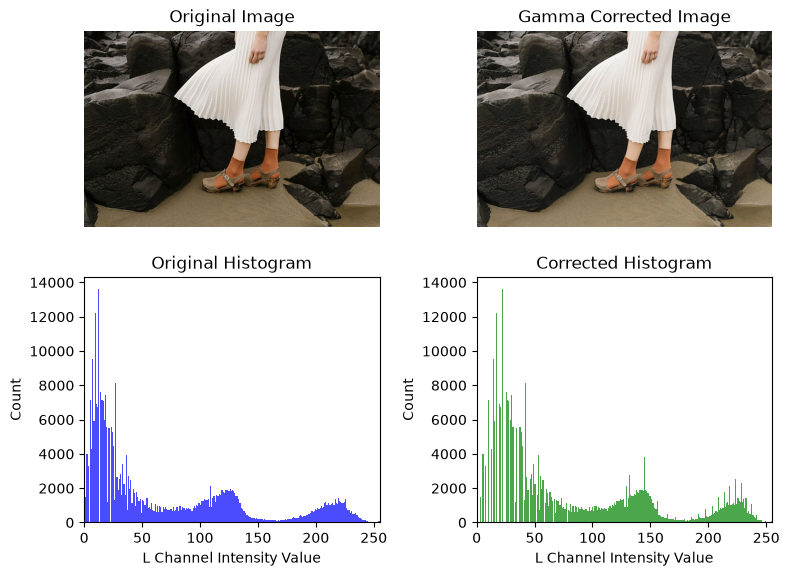

In [ ]:
def gamma_correction(im_lab, gamma):
    '''Apply gamma correction to the image in L*a*b color space.'''
    l_channel, a_im, b_channel = cv.split(im_lab)
    l_channel = np.power(l_channel / 255.0, gamma) * 255.0
    l_channel = np.clip(l_channel, 0, 255).astype(np.uint8)
    corrected_im_lab = cv.merge((l_channel, a_channel, b_channel))
    return corrected_im_lab

im = cv.imread('images/highlights_and_shadows.jpg')
assert im is not None, "Image not found. Please check the path."
im_lab = cv.cvtColor(im, cv.COLOR_BGR2Lab)

# Apply gamma correction
gamma = 0.8
corrected_im_lab = gamma_correction(im_lab, gamma)

# Display the original and corrected images alongside their histograms
fig, ax = plt.subplots(2, 2, figsize=(8, 6))

ax[0, 0].imshow(cv.cvtColor(im_lab, cv.COLOR_Lab2RGB))
ax[0, 0].set_title('Original Image')
ax[0, 0].axis('off')

ax[0, 1].imshow(cv.cvtColor(corrected_im_lab, cv.COLOR_Lab2RGB))
ax[0, 1].set_title('Gamma Corrected Image')
ax[0, 1].axis('off')

ax[1, 0].hist(cv.split(im_lab)[0].ravel(), bins=256, color='blue', alpha=0.7)
ax[1, 0].set_title('Original Histogram')
ax[1, 0].set_xlim(0, 255)
ax[1, 0].set_xlabel('L Channel Intensity Value')
ax[1, 0].set_ylabel('Count')

ax[1, 1].hist(cv.split(corrected_im_lab)[0].ravel(), bins=256, color='green', alpha=0.7)
ax[1, 1].set_title('Corrected Histogram')
ax[1, 1].set_xlim(0, 255)
ax[1, 1].set_xlabel('L Channel Intensity Value')
ax[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

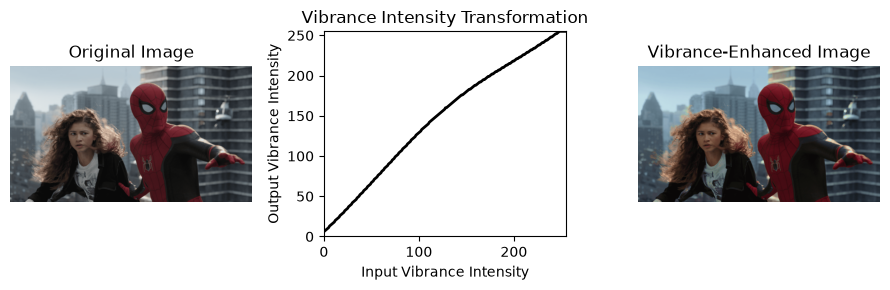

In [6]:
im = cv.imread('images/spider.png')
assert im is not None, "Image not found. Please check the path."

f = lambda x, a, sigma=70: np.minimum(x + a * 128 * np.exp(-((x - 128) ** 2) / (2 * sigma ** 2)), 255).astype(np.uint8)

im_hsv = cv.cvtColor(im, cv.COLOR_BGR2HSV)
h_channel, s_channel, v_channel = cv.split(im_hsv)

s_channel_enhanced = f(s_channel, a=0.25)  # Adjust 'a' as needed
im_enhanced = cv.merge([h_channel, s_channel_enhanced, v_channel])

fig, ax = plt.subplots(1, 3, figsize=(9, 3))

ax[0].imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB))
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].plot(np.arange(256), f(np.arange(256), a=0.25), 'black', linewidth=2)
ax[1].set_xlabel('Input Vibrance Intensity')
ax[1].set_ylabel('Output Vibrance Intensity')
ax[1].set_title('Vibrance Intensity Transformation')
ax[1].set_xlim(0, 255)
ax[1].set_ylim(0, 255)

ax[2].imshow(cv.cvtColor(im_enhanced, cv.COLOR_HSV2RGB))
ax[2].set_title('Vibrance-Enhanced Image')
ax[2].axis('off')

plt.tight_layout()
plt.show()

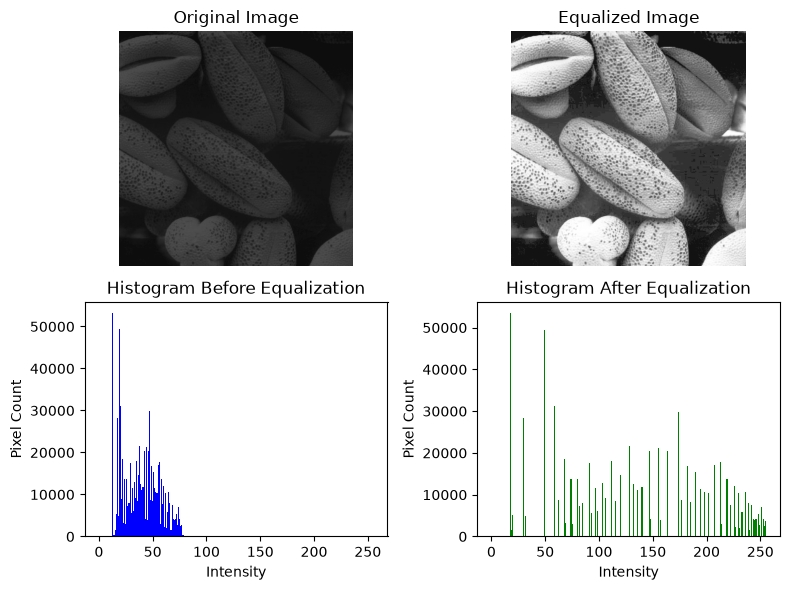

In [14]:

'''Write a function of your own to carry out histogram equalization on the image shown in Fig. 5. Show the histograms before and after equalization'''

def histogram_equalization(im, flag=cv.IMREAD_GRAYSCALE):
    # Calculate the histogram

    n_k = np.bincount(im.flatten(), minlength=256)
    n_k_sum = np.cumsum(n_k)
    n = im.size

    # Calculate the transformation function
    f = np.round(n_k_sum / (n) * 255).astype(np.uint8)

    # Apply the transformation to the image
    equalized_im = f[im]

    return equalized_im

im = cv.imread('images/shells.tif')
assert im is not None, "Image not found. Please check the path."

im_equalized = histogram_equalization(im)

fig, ax = plt.subplots(2, 2, figsize=(8, 6))

ax[0, 0].imshow(im, cmap='gray')
ax[0, 0].set_title('Original Image')
ax[0, 0].axis('off')

ax[0, 1].imshow(im_equalized, cmap='grey')
ax[0, 1].set_title('Equalized Image')
ax[0, 1].axis('off')    

hist_before = np.bincount(im.ravel(), minlength=256)
hist_after = np.bincount(im_equalized.ravel(), minlength=256)

ax[1, 0].bar(np.arange(256), hist_before, color='blue', width=1)
ax[1, 0].set_title('Histogram Before Equalization')
ax[1, 0].set_xlabel('Intensity')
ax[1, 0].set_ylabel('Pixel Count')

ax[1, 1].bar(np.arange(256), hist_after, color='green', width=1)
ax[1, 1].set_title('Histogram After Equalization')
ax[1, 1].set_xlabel('Intensity')
ax[1, 1].set_ylabel('Pixel Count')


plt.tight_layout()
plt.show()

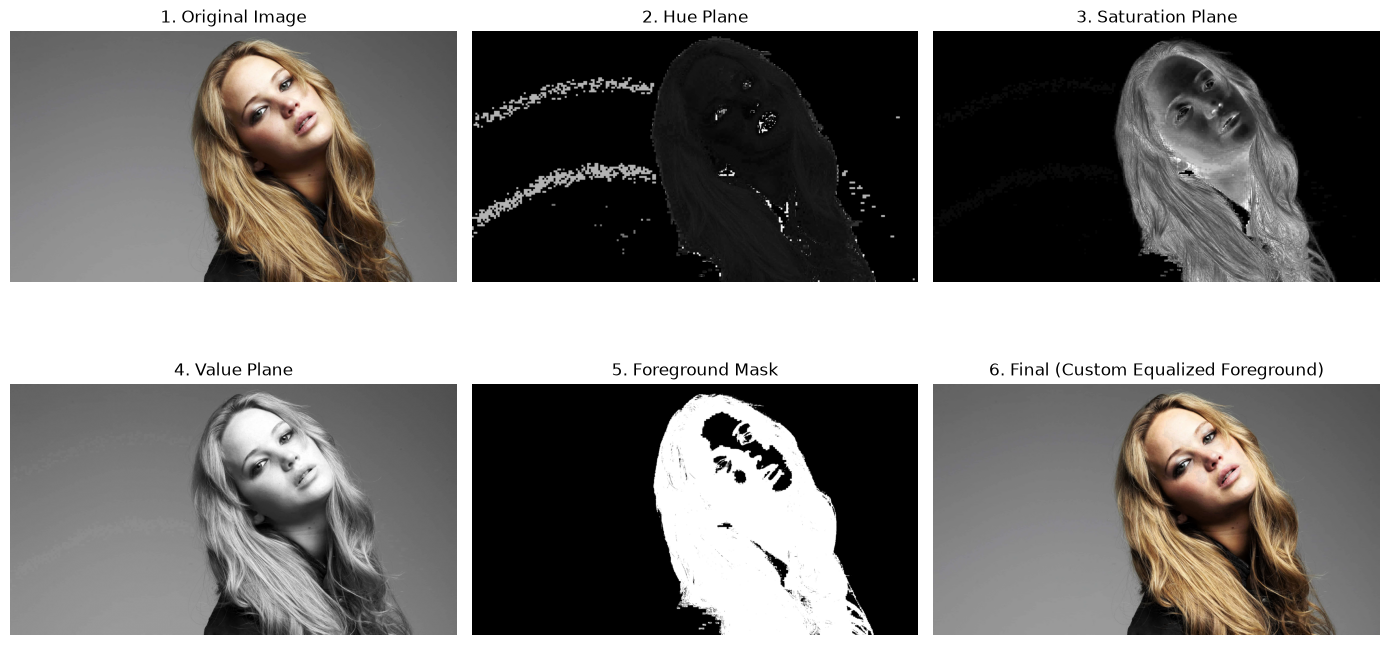

In [31]:
def custom_histogram_equalization(foreground, mask=None):
    L = 256  

    if mask is not None:
        fg_pixels = foreground[mask > 0]
        n = fg_pixels.size

        if n == 0:
            return foreground.copy()
            
        n_k = np.bincount(fg_pixels, minlength=L)
    else:
        n = foreground.size
        n_k = np.bincount(foreground.flatten(), minlength=L)

    n_k_sum = np.cumsum(n_k)
    f = np.round(((L - 1) / n) * n_k_sum).astype(np.uint8)
    fg_equalized = f[foreground]

    return fg_equalized

im = cv.imread('images/jeniffer.jpg')
assert im is not None, "Image not found. Please check the path."

im_hsv = cv.cvtColor(im, cv.COLOR_BGR2HSV)
h_channel, s_channel, v_channel = cv.split(im_hsv)

_, mask = cv.threshold(s_channel, 50, 255, cv.THRESH_BINARY)
mask_inv = cv.bitwise_not(mask)

background = cv.bitwise_and(im, im, mask=mask_inv)
foreground = cv.bitwise_and(im, im, mask=mask)

fg_hsv = cv.cvtColor(foreground, cv.COLOR_BGR2HSV)
fg_h, fg_s, fg_v = cv.split(fg_hsv)

fg_v_equalized = custom_histogram_equalization(fg_v, mask=mask)

fg_hsv_equalized = cv.merge([fg_h, fg_s, fg_v_equalized])
equalized_foreground = cv.cvtColor(fg_hsv_equalized, cv.COLOR_HSV2BGR)
equalized_foreground = cv.bitwise_and(equalized_foreground, equalized_foreground, mask=mask)

final_result = cv.add(background, equalized_foreground)

fig, ax = plt.subplots(2, 3, figsize=(14, 8))

ax[0, 0].imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB))
ax[0, 0].set_title('1. Original Image')
ax[0, 0].axis('off')

ax[0, 1].imshow(h_channel, cmap='gray')
ax[0, 1].set_title('2. Hue Plane')
ax[0, 1].axis('off')

ax[0, 2].imshow(s_channel, cmap='gray')
ax[0, 2].set_title('3. Saturation Plane')
ax[0, 2].axis('off')

ax[1, 0].imshow(v_channel, cmap='gray')
ax[1, 0].set_title('4. Value Plane')
ax[1, 0].axis('off')

ax[1, 1].imshow(mask, cmap='gray')
ax[1, 1].set_title('5. Foreground Mask')
ax[1, 1].axis('off')

ax[1, 2].imshow(cv.cvtColor(final_result, cv.COLOR_BGR2RGB))
ax[1, 2].set_title('6. Final (Custom Equalized Foreground)')
ax[1, 2].axis('off')

plt.tight_layout()
plt.show()

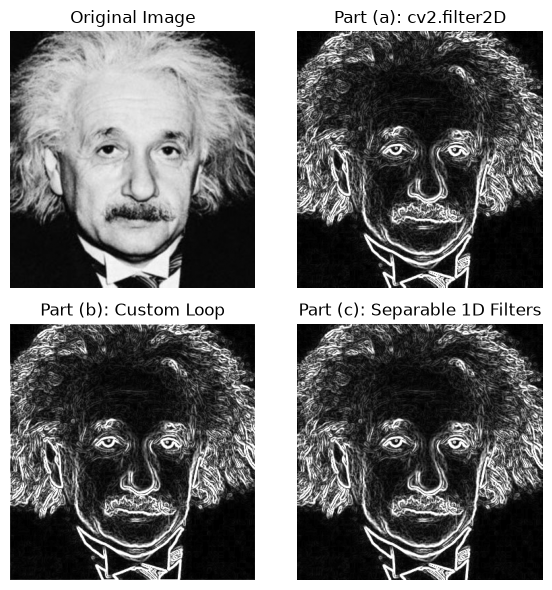

In [45]:
im = cv.imread('images/einstein.png', cv.IMREAD_GRAYSCALE)
assert im is not None, "Image not found. Please check the path."

# Part (a)
sobel_x = np.array([
    [-1,  0,  1],
    [-2,  0,  2],
    [-1,  0,  1]
], dtype=np.float32)

sobel_y = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype=np.float32)

grad_x_a = cv.filter2D(im, cv.CV_64F, sobel_x)
grad_y_a = cv.filter2D(im, cv.CV_64F, sobel_y)

im_sobel_a = np.sqrt(grad_x_a**2 + grad_y_a**2)
im_sobel_a = cv.convertScaleAbs(im_sobel_a)

# Part(b)
def custom_sobel_filter(image):
    H, W = image.shape
    
    sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float64)
    sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float64)
    
    # Pad image to handle borders (zero-padding)
    padded_img = np.pad(image, ((1, 1), (1, 1)), mode='constant', constant_values=0)
    
    grad_x = np.zeros((H, W), dtype=np.float64)
    grad_y = np.zeros((H, W), dtype=np.float64)
    
    # Perform 2D cross-correlation / convolution manually
    for i in range(H):
        for j in range(W):
            region = padded_img[i:i+3, j:j+3]
            grad_x[i, j] = np.sum(region * sobel_x)
            grad_y[i, j] = np.sum(region * sobel_y)
            
    magnitude = np.sqrt(grad_x**2 + grad_y**2)
    return np.uint8(np.clip(magnitude, 0, 255))

im_sobel_b = custom_sobel_filter(im)

# Part (c)
v_gaussian = np.array([[1], [2], [1]], dtype=np.float32)      
h_diff     = np.array([[1, 0, -1]], dtype=np.float32)         

v_diff     = np.array([[1], [0], [-1]], dtype=np.float32)     
h_gaussian = np.array([[1, 2, 1]], dtype=np.float32)          

grad_x_c = cv.sepFilter2D(im, cv.CV_64F, h_diff, v_gaussian)
grad_y_c = cv.sepFilter2D(im, cv.CV_64F, h_gaussian, v_diff)

im_sobel_c = np.sqrt(grad_x_c**2 + grad_y_c**2)
im_sobel_c = cv.convertScaleAbs(im_sobel_c)


fig, ax = plt.subplots(2, 2, figsize=(6, 6))

# (0, 0): Original Image
ax[0, 0].imshow(im, cmap='gray')
ax[0, 0].set_title('Original Image')
ax[0, 0].axis('off')

# (0, 1): Part (a)
ax[0, 1].imshow(im_sobel_a, cmap='gray')
ax[0, 1].set_title('Part (a): cv2.filter2D')
ax[0, 1].axis('off')

# (1, 0): Part (b)
ax[1, 0].imshow(im_sobel_b, cmap='gray')
ax[1, 0].set_title('Part (b): Custom Loop')
ax[1, 0].axis('off')

# (1, 1): Part (c)
ax[1, 1].imshow(im_sobel_c, cmap='gray')
ax[1, 1].set_title('Part (c): Separable 1D Filters')
ax[1, 1].axis('off')

plt.tight_layout()
plt.show()

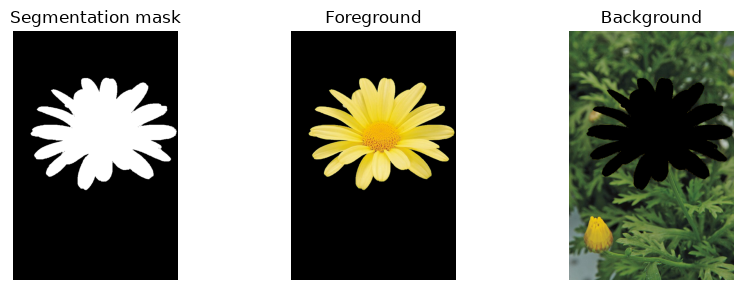

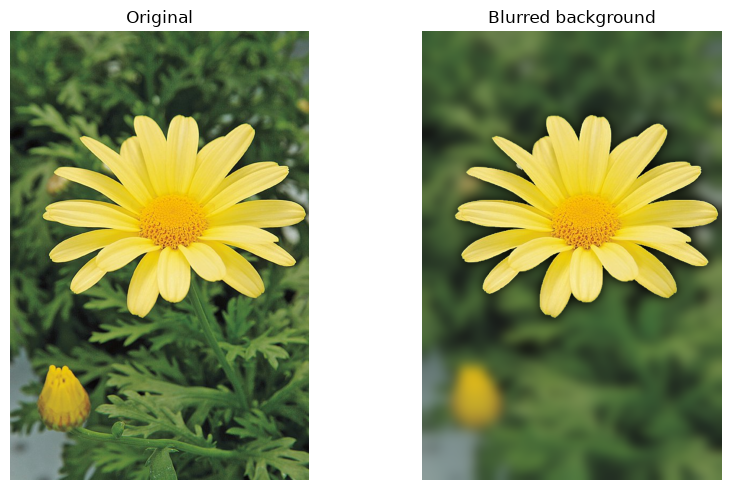

In [94]:
im = cv.imread("images/daisy.jpg")
H, W, C = im.shape

mask = np.zeros((H, W), np.uint8)
bgd_model = np.zeros((1, 65), np.float64)
fgd_model = np.zeros((1, 65), np.float64)

rect = (int(W * 0.03), int(H * 0.1), int(W * 0.97), int(H * 0.6))

cv.grabCut(im, mask, rect, bgd_model, fgd_model, 5, cv.GC_INIT_WITH_RECT)
binary_mask = np.where((mask == 2) | (mask == 0), 0, 1).astype(np.uint8)

foreground = im * binary_mask[:, :, None]
background = im * (1 - binary_mask[:, :, None])

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(binary_mask, cmap='gray'); axes[0].set_title("Segmentation mask"); axes[0].axis('off')
axes[1].imshow(cv.cvtColor(foreground, cv.COLOR_BGR2RGB)); axes[1].set_title("Foreground"); axes[1].axis('off')
axes[2].imshow(cv.cvtColor(background, cv.COLOR_BGR2RGB)); axes[2].set_title("Background"); axes[2].axis('off')
plt.tight_layout(); plt.show()

def blur_background(img, binary_mask, ksize=31):
    """
    Blurs the masked-out background (foreground zeroed to black first) -- the natural
    first implementation, and the one that produces the dark-halo artifact discussed below.
    """
    bg_only = img * (1 - binary_mask[:, :, None])
    blurred_bg = cv.GaussianBlur(bg_only, (ksize, ksize), 0)
    fg = img * binary_mask[:, :, None]
    return (fg + blurred_bg * (1 - binary_mask[:, :, None])).astype(np.uint8)

enhanced = blur_background(im, binary_mask, ksize=71)

fig, axes = plt.subplots(1, 2, figsize=(9, 5))
axes[0].imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB)); axes[0].set_title("Original"); axes[0].axis('off')
axes[1].imshow(cv.cvtColor(enhanced, cv.COLOR_BGR2RGB)); axes[1].set_title("Blurred background"); axes[1].axis('off')
plt.tight_layout(); plt.show()